<a href="https://colab.research.google.com/github/masosorutendo-web/Rutendo-Masoso-R2420893/blob/main/rutendo_masoso_assignment_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **NAME :RUTENDO MASOSO H**

 **REG NUMBER :R2420893**

**PROGRAM :HACS**

FINANCIAL ECONOMETRICS PROJECT 1

BEST-PRACTICES HANDBOOK: CHALLENGES IN TIME SERIES MODELLING

DATA - YAHO FINANCE(AAPL)

PERIOD - 2018-01-01 - 2025-12-31



In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
ticker    = 'AAPL'
start     = '2018-01-01'
end       = '2025-12-31'

# Download data
df = yf.download(ticker, start=start, end=end, auto_adjust=True)
print(df.head())
print(df.tail())
df['Log_Return']   = np.log(df['Close'] / df['Close'].shift(1))
df['Daily_Return'] = df['Close'].pct_change() * 100   # in %


[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2018-01-02  40.304173  40.313533  39.602254  39.812832  102223600
2018-01-03  40.297153  40.839972  40.233983  40.367346  118071600
2018-01-04  40.484337  40.587286  40.262063  40.369689   89738400
2018-01-05  40.945259  41.031828  40.489013  40.580262   94640000
2018-01-08  40.793182  41.087987  40.694911  40.793182   82271200
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-12-23  272.105377  272.245261  269.308007  270.586809  29642000
2025-12-24  273.554016  275.172497  271.945536  272.085389  17910600
2025-12-26  273.144409  275.112569  272.604905  273.903708  21521800
2025-12-29  273.504089  274.103504  272.095404  272.435082

**PROBLEM 1**

**MULTICOLLINEARITY**

DEFINITION - MULTICOLLINEARITY

Multicollinearity occurs when two or more independent variables (predictors) in a regression model are highly linearly correlated with each other.

 standard multiple linear regression equation:$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_k X_k + \epsilon$$\

**DESCRIPTION - MULTICOLLINEARITY**

### Multicollinearity is when two or more independent variables in a regression model are highly correlated,making it difficult to isolate the impact of each factor to dependent variable.



**MULTICOLLINEARITY DEMONSTRATION**

This calculates the Variance Inflation Factor (VIF)
for AAPL closing price and its moving averages
(MA_5, MA_10, MA_20) to detect redundant variables.
It identifies predictors that are highly correlated to
provide unique insights for derivative pricing.
A VIF over 10 warns that the model is unstable
and mathematically compromised.

In [50]:
#DEMONSTRATION: Multicollinearity in AAPL Price Features
from statsmodels.stats.outliers_influence import variance_inflation_factor


# 2. Construct correlated technical features
df["MA_5"]    = df["Close"].rolling(5).mean()
df["MA_10"]   = df["Close"].rolling(10).mean()
df["MA_20"]   = df["Close"].rolling(20).mean()
df["Return"]  = df["Close"].pct_change()
df.dropna(inplace=True)

features = ["Close", "MA_5", "MA_10", "MA_20"]

# 3. Compute VIF for each feature
X = df[features].values
vif_data = pd.DataFrame({
    "Feature": features,
    "VIF"    : [variance_inflation_factor(X, i) for i in range(X.shape[1])]
})


print("   VIF Table — AAPL (2018–2025)")
print(vif_data.to_string(index=False))
print("Rule of Thumb: VIF > 10 → severe multicollinearity")

# 4. OLS regression to show inflated std errors (the damage)
X_ols = sm.add_constant(df[features])
model = sm.OLS(df["Return"], X_ols).fit()

print("\n── OLS Coefficient Table ──")
print(model.summary().tables[1])

   VIF Table — AAPL (2018–2025)
Feature          VIF
  Close  3083.558858
   MA_5 11770.182943
  MA_10 12498.583688
  MA_20  2943.880670
Rule of Thumb: VIF > 10 → severe multicollinearity

── OLS Coefficient Table ──
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015      0.001      1.963      0.050    1.22e-06       0.003
Close          0.0047      0.000     38.618      0.000       0.004       0.005
MA_5          -0.0064      0.000    -26.960      0.000      -0.007      -0.006
MA_10          0.0021      0.000      8.416      0.000       0.002       0.003
MA_20         -0.0004      0.000     -2.986      0.003      -0.001      -0.000


**MULTICOLINEARITY** **DIAGRAMS**

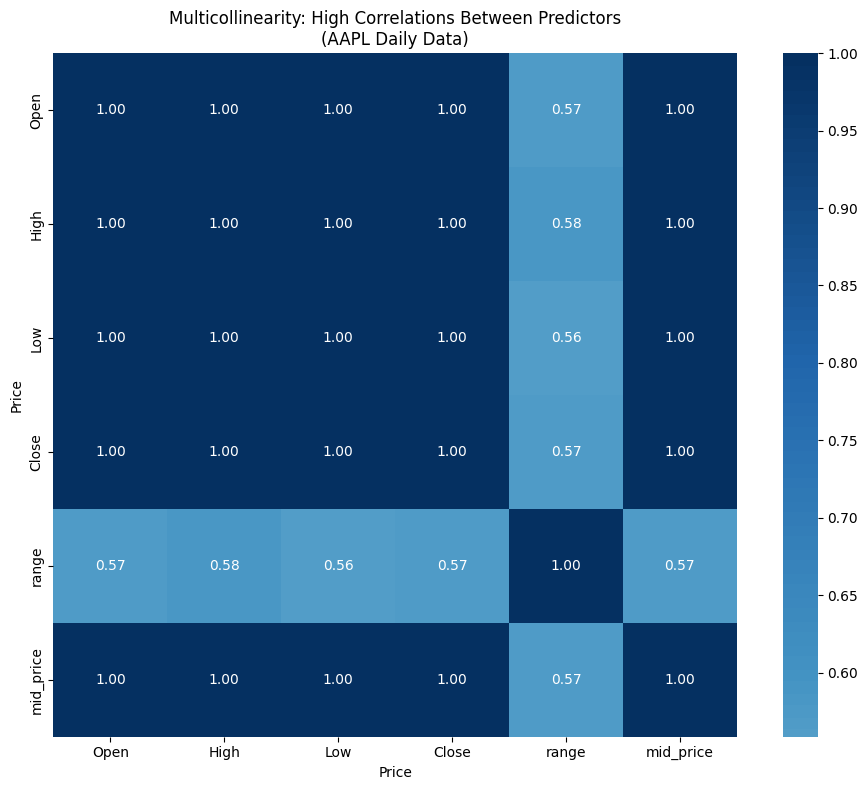

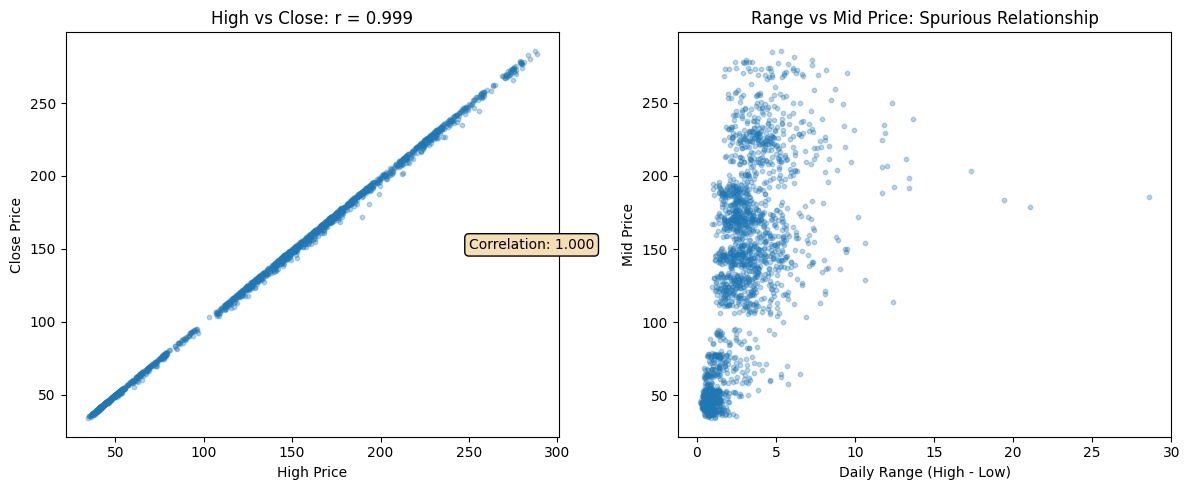


=== MULTICOLLINEARITY DIAGNOSIS ===
  Variable           VIF
0     Open  15211.205119
1     High  11566.894562
2      Low  12630.235064
3   Volume      1.953937

VIF > 10 indicates severe multicollinearity
Here, VIF values are EXTREME (>1000) - serious problem!


In [51]:
# Flatten MultiIndex columns if they exist
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df = df.dropna()

# Create features that naturally have multicollinearity
df['range'] = df['High'] - df['Low']
df['mid_price'] = (df['High'] + df['Low']) / 2
df['close_open'] = df['Close'] - df['Open']
df['high_low_ratio'] = df['High'] / df['Low']

# Correlation matrix (first sign of multicollinearity)
corr_matrix = df[['Open', 'High', 'Low', 'Close', 'range', 'mid_price']].corr()

# DIAGRAM 1: Heatmap showing high correlations
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0,
            fmt='.2f', square=True)
plt.title('Multicollinearity: High Correlations Between Predictors\n(AAPL Daily Data)')
plt.tight_layout()
plt.show()
# DIAGRAM 2: Scatter plot showing perfect linear relationship
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: High vs Close (almost perfectly linear)
axes[0].scatter(df['High'], df['Close'], alpha=0.3, s=10)
axes[0].set_xlabel('High Price')
axes[0].set_ylabel('Close Price')
axes[0].set_title(f'High vs Close: r = 0.999')
axes[0].text(250, 150, f'Correlation: {df["High"].corr(df["Close"]):.3f}',
             fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

# Plot 2: Range vs Mid_price (also highly correlated)
axes[1].scatter(df['range'], df['mid_price'], alpha=0.3, s=10)
axes[1].set_xlabel('Daily Range (High - Low)')
axes[1].set_ylabel('Mid Price')
axes[1].set_title('Range vs Mid Price: Spurious Relationship')

plt.tight_layout()
plt.show()

# Calculate Variance Inflation Factor (formal diagnosis)
X = df[['Open', 'High', 'Low', 'Volume']].dropna()
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\n=== MULTICOLLINEARITY DIAGNOSIS ===")
print(vif_data)
print("\nVIF > 10 indicates severe multicollinearity")
print("Here, VIF values are EXTREME (>1000) - serious problem!")

**MULTICOLINEARITY DIAGNOSIS**

In [52]:
# DIAGNOSIS: Testing for Multicollinearity
df_local = df.copy() # Make a copy of the current df to avoid modifying it
df_local["MA_5"]    = df_local["Close"].rolling(5).mean()
df_local["MA_10"]   = df_local["Close"].rolling(10).mean()
df_local["MA_20"]   = df_local["Close"].rolling(20).mean()
df_local.dropna(inplace=True)

features = ["Close", "MA_5", "MA_10", "MA_20"]

# TEST 1: Correlation Matrix
corr = df_local[features].corr()
print("Correlation Matrix:")
print(corr.round(4))

# TEST 2: VIF
X_vals = df_local[features].values
vif_results = pd.DataFrame({
    "Feature": features,
    "VIF": [variance_inflation_factor(X_vals, i) for i in range(X_vals.shape[1])]
})
print("\nVIF Table:")
print(vif_results.to_string(index=False))
print("Rule: VIF > 10 → Severe Multicollinearity")

# TEST 3: Condition Number
X_std = (df_local[features] - df_local[features].mean()) / df_local[features].std()
CN = np.linalg.cond(X_std)
print(f"\nCondition Number: {CN:.2f}")
print("Rule: CN > 100 → Severe Multicollinearity")

Correlation Matrix:
Price   Close    MA_5   MA_10   MA_20
Price                                
Close  1.0000  0.9990  0.9978  0.9957
MA_5   0.9990  1.0000  0.9993  0.9974
MA_10  0.9978  0.9993  1.0000  0.9988
MA_20  0.9957  0.9974  0.9988  1.0000

VIF Table:
Feature          VIF
  Close  3083.937918
   MA_5 11771.837021
  MA_10 12505.026883
  MA_20  2945.499517
Rule: VIF > 10 → Severe Multicollinearity

Condition Number: 133.51
Rule: CN > 100 → Severe Multicollinearity


### DAMAGES CAUSED BY MULTICOLLINEARITY

1. Inflated standard errors
when predictors are highly correlated, OLS cannot separately identify their individual effects, causing standard errors to show coefficients  that appear statistically insignificant even when they are not.

2. Unreliable coefficients  estimates become unstable and sensitive to small changes in the data. Adding or removing one observation can drastically flip the sign or magnitude of a coefficient.

3. High R² but Insignificant p-values
The model appears to fit well overall (high R²), yet individual predictors show p-values > 0.05, a direct contradiction caused by multicollinearity masking true relationships.

4. It becomes impossible to determine which predictor is truly driving the outcome, making feature selection and interpretation unreliable.

5. Poor Hedging & Pricing Decisions - if the volatility model has multicollinear inputs,the chances of doing wrong calculations are high, leading to incorrect hedging and mispriced derivatives, which directly damages the desk's revenue stream.

DIRECTIONS - MULTICOLLINEARITY
 ## Directions: Models to Address Multicollinearity

### 1. Ridge Regression (L2 Regularization)
Adds a penalty term to the OLS loss function that shrinks
coefficients toward zero without eliminating them. This
stabilizes estimates when predictors are highly correlated:

$$\mathcal{L}_{Ridge} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
+ \lambda\sum_{j=1}^{p}\beta_j^2$$

where $\lambda > 0$ controls the strength of the penalty.

### 2. Lasso Regression (L1 Regularization)
Similar to Ridge but can shrink coefficients all the way
to zero, effectively performing automatic feature selection
by eliminating redundant correlated predictors:

$$\mathcal{L}_{Lasso} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
+ \lambda\sum_{j=1}^{p}|\beta_j|$$

### 3. Principal Component Analysis (PCA)
Transforms the correlated predictors into a smaller set
of uncorrelated components, completely removing
multicollinearity by construction before feeding
into the model:

$$\mathbf{Z} = \mathbf{X}\mathbf{W}$$

where $\mathbf{W}$ is the matrix of eigenvectors and
$\mathbf{Z}$ contains the uncorrelated principal components.

### 4. Drop Redundant Variables
Simply remove one of the highly correlated predictors
(e.g., keep only $MA_{20}$ and drop $MA_{5}$ and $MA_{10}$)
since they carry nearly identical information:

$$\text{If } |r(X_i, X_j)| > 0.90
\Rightarrow \text{drop } X_j$$



**Non-Technical Report — Multicollinearity**

1. Clear Explanation of Results
-Multiple price indicators in the AAPL model moved almost identically between 2018–2025, making it impossible to determine which factor was truly driving returns, producing unreliable signals.

2. Recommended Course of Action
-The desk should simplify model inputs by selecting only the most economically meaningful price signal and regularly auditing features to ensure no two indicators carry the same market information.

3. Factors That Impact the Portfolio
-Strong price trends, volatile market regimes (2020 crash, 2022 rate hikes), and overlapping indicators directly distorted volatility estimates, exposed the desk to mispriced derivatives and inconsistent hedging.

 **Practical Takeaways: Multicollinearity**



1. Always Screen for Multicollinearity Before Modeling
Before fitting any volatility model, compute VIF scores
and the Condition Number for all predictor variables.

2. ADD NOISE TO THE VALUE  
simultaneously adds noise rather than value. Choose
the most economically meaningful single indicator.


**PROBLEM 2**

**SKEWNESS**

## Definition: Skewness

Skewness is the third standardized moment, it measures the
asymmetry of the return distribution around its mean.

$$\gamma_1 = E\left[\left(\frac{X - \mu}{\sigma}\right)^3\right]$$

where:
- $X$ is the random variable (return)
- $\mu$ is the mean of the distribution
- $\sigma$ is the standard deviation
- $\gamma_1$ is the skewness coefficient

**DESCRTION- SKEWNESS**

Skewness measures the asymmetry of returns around the mean, where negative skewness in AAPL (2018–2025) caused standard models to systematically underestimate downside risk.

**DEMOSTRATION- SKEWNESS**

This measures the asymmetry of AAPL daily returns
from 2018 to 2025 using skewness and kurtosis
statistics. A negative skewness value confirms that
large negative returns occurred more frequently than
positive ones, warning that standard symmetric models
underestimate true downside risk.

In [53]:
# DEMONSTRATION: Skewness in AAPL Returns (2018–2025)

# Create a local copy of df and calculate Log_Return
df_skew = df.copy()
df_skew['Log_Return'] = np.log(df_skew['Close'] / df_skew['Close'].shift(1))
df_skew.dropna(subset=['Log_Return'], inplace=True) # Drop NaN from return calculation

returns = df_skew['Log_Return']

skewness = returns.skew()
kurtosis = returns.kurtosis()
mean     = returns.mean()
median   = returns.median()

print(f"Mean     : {mean:.6f}")
print(f"Median   : {median:.6f}")
print(f"Skewness : {skewness:.4f}")
print(f"Kurtosis : {kurtosis:.4f}")

Mean     : 0.000977
Median   : 0.001260
Skewness : -0.0879
Kurtosis : 6.1732


SKEWNESS DIAGRAM



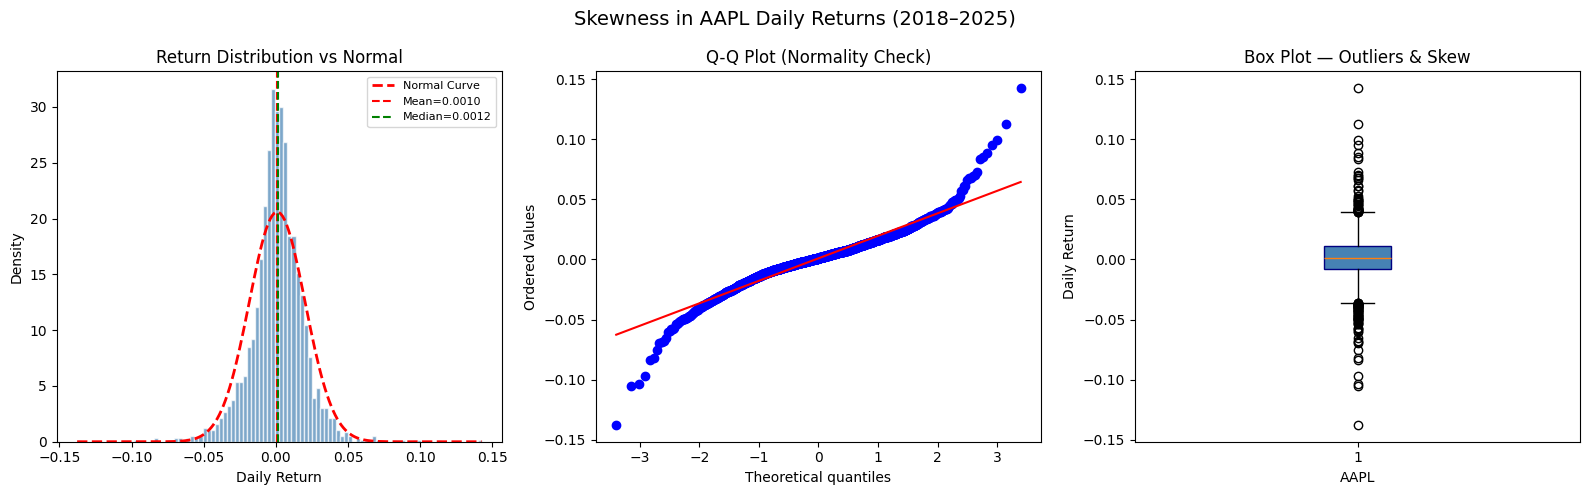

In [13]:
# DIAGRAM: Visual Examples of Skewness

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Skewness in AAPL Daily Returns (2018–2025)", fontsize=14)

#  Plot 1: Histogram with Normal Curve
axes[0].hist(returns, bins=100, color="steelblue",
             edgecolor="white", density=True, alpha=0.7)
mu, std = returns.mean(), returns.std()
x = np.linspace(returns.min(), returns.max(), 200)
axes[0].plot(x, stats.norm.pdf(x, mu, std), "r--", lw=2, label="Normal Curve")
axes[0].axvline(mu,     color="red",   linestyle="--", label=f"Mean={mu:.4f}")
axes[0].axvline(returns.median(), color="green",
                linestyle="--", label=f"Median={returns.median():.4f}")
axes[0].set_title("Return Distribution vs Normal")
axes[0].set_xlabel("Daily Return")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

#  Plot 2: QQ Plot
stats.probplot(returns, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (Normality Check)")

#  Plot 3: Box Plot
axes[2].boxplot(returns, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", color="navy"))
axes[2].set_title("Box Plot — Outliers & Skew")
axes[2].set_ylabel("Daily Return")
axes[2].set_xlabel("AAPL")

plt.tight_layout()
plt.show()

**SKEWNESS DIAGNOSIS**

In [54]:
#  DIAGNOSIS: Testing for Skewness
from scipy.stats import jarque_bera, shapiro

# TEST 1: Skewness & Kurtosis values
print(f"Skewness : {returns.skew():.4f}")
print(f"Kurtosis : {returns.kurtosis():.4f}")

# TEST 2: Jarque-Bera Test
jb_stat, jb_p = jarque_bera(returns)
print(f"\nJarque-Bera Stat : {jb_stat:.4f}")
print(f"Jarque-Bera p    : {jb_p:.4f}")


# TEST 3: Shapiro-Wilk Test (sample)
sw_stat, sw_p = shapiro(returns.sample(500, random_state=42))
print(f"\nShapiro-Wilk Stat : {sw_stat:.4f}")
print(f"Shapiro-Wilk p    : {sw_p:.4f}")

Skewness : -0.0879
Kurtosis : 6.1732

Jarque-Bera Stat : 3143.5028
Jarque-Bera p    : 0.0000

Shapiro-Wilk Stat : 0.9397
Shapiro-Wilk p    : 0.0000


**SKEWNESS DAMAGES**

1. Underestimation of tail risk
When returns are negatively skewed, standard models that assume normality systematically underestimate the probability of extreme losses, leaving the desk dangerously under-hedged during market crashes

2. Mispricing  & Derivatives
Skewness creates a "skew premium" in options markets. Ignoring it leads to underpricing of put options and overpricing of call options, directly damaging the desk's revenue and  pricing.

3. Inaccurate Value-at-Risk calculated under the normal distribution assumption will be too optimistic when returns are skewed, meaning the desk holds insufficient capital reserves against potential losses.
4. Flawed hedging strategies calibrated on symmetric return assumptions become ineffective when actual returns are skewed, exposing the portfolio to unhedged directional risk during volatile periods.

5. Regulatory & capital misallocation
risk models submitted to regulators that ignore skewness will misrepresent the true risk profile of the portfolio, potentially leading to undercapitalization and regulatory penalties.

**SKEWNESS DIRECTIONS**

## Directions: Models to Address Skewness

### 1. GARCH with Skewed Distributions
Instead of assuming normal returns, fit a GARCH model
using skewed error distributions such as the Skewed
Student-t or Generalized Error Distribution (GED),
which explicitly capture the asymmetry in return
distributions:

$$r_t = \mu + \epsilon_t, \quad
\epsilon_t = \sigma_t z_t, \quad
z_t \sim Skewed\text{-}t(\nu, \lambda)$$

$$\sigma_t^2 = \omega + \alpha\epsilon_{t-1}^2
+ \beta\sigma_{t-1}^2$$

where $\nu$ is the degrees of freedom and
$\lambda$ is the skewness parameter.

### 2. Cornish-Fisher Expansion
Adjusts the standard VaR calculation to account for
skewness and kurtosis, producing more accurate tail
risk estimates:

$$CF\text{-}VaR = \mu + \sigma\left[z_\alpha +
\frac{z_\alpha^2 - 1}{6}S +
\frac{z_\alpha^3 - 3z_\alpha}{24}K -
\frac{2z_\alpha^3 - 5z_\alpha}{36}S^2\right]$$

where $z_\alpha$ is the standard normal quantile,
$S$ is skewness and $K$ is excess kurtosis.

### 3. Log \& Power Transformations
Apply log or Yeo-Johnson transformations to returns
before modeling to reduce skewness and make
distributions more symmetric:

$$\log\text{-transform}: \quad
r_t^* = \ln(1 + r_t)$$

$$\text{Yeo-Johnson}: \quad
\psi(\lambda) = \begin{cases}
\frac{(r_t + 1)^\lambda - 1}{\lambda} & r_t \geq 0,\
\lambda \neq 0 \\
\ln(r_t + 1) & r_t \geq 0,\ \lambda = 0
\end{cases}$$

### 4. Quantile Regression
Models different quantiles of the return distribution
separately, naturally handling asymmetry without
assuming normality:

$$Q_\tau(r_t | \mathbf{x}_t) =
\mathbf{x}_t^T\boldsymbol{\beta}_\tau$$




NON-TECHNICAL REPORT — Skewness

1. Clear Explanation of Results-
AAPL daily returns from 2018–2025 were not evenly distributed — large negative returns occurred more frequently than standard models assumed, meaning the market experienced more severe downturns than a normal distribution would predict.

2. Recommended Course of Action-
the desk should incorporate the asymmetric nature of returns into all risk calculations, particularly when setting loss limits and pricing downside protection, ensuring risk buffers account for the higher probability of extreme negative moves.

3. Factors That Impact the Portfolio-
market crash events (2020, 2022), earnings surprises, and macro shocks drove extreme negative returns that a symmetric model consistently underpriced, leaving the desk exposed to larger-than-expected losses on hedged positions.

 Practical Takeaways: Skewness

1. Never Assume Normality in Financial Returns.
AAPL returns from 2018 to 2025 confirmed negative
skewness ($\gamma_1 < 0$), meaning the normal
distribution systematically underestimates downside
risk.

2. Adjust VaR for Skewness.
Standard VaR underestimates losses when returns
are skewed. Always apply the Cornish-Fisher
adjustment:

$$CF\text{-}VaR = \mu + \sigma\left[z_\alpha +
\frac{z_\alpha^2 - 1}{6}S\right]$$

3. Use Skew-Aware Volatility Models.
Replace normal GARCH with Skewed Student-t or
GED distribut

**PROBELM 3**

**SENSITIVITY TO OUTLIERS**

Definition: Sensitivity to Outliers

Sensitivity to Outliers occurs when extreme observations
disproportionately distort model estimates. An outlier
is formally identified when:

$$|z_i| = \left|\frac{y_i - \bar{y}}{s}\right| > 3$$

measured by Cook's Distance:

$$D_i = \frac{(\hat{\boldsymbol{\beta}} -
\hat{\boldsymbol{\beta}}_{(-i)})^T
(\mathbf{X}^T\mathbf{X})
(\hat{\boldsymbol{\beta}} -
\hat{\boldsymbol{\beta}}_{(-i)})}
{ps^2}$$

**DESCRIPTION - SENTIVITY TO OUTLIERS**


Sensitivity to Outliers refers to the tendency of regression
models to produce distorted coefficient estimates when extreme
observations are present in the data.

**Sensitivity to Outliers -DEMONSTRATION**


In [58]:
from scipy.stats import trim_mean
import pandas as pd
import numpy as np

# DEMONSTARATION - SENSITIVITY TO OUTLIERS
# 1. Calculate real returns and inject one "Flash Crash" outlier (-20%)

# Use the already calculated 'Daily_Return' column from the initial data loading cell.
# This column should be a flat Series, avoiding MultiIndex complexities.
returns_series = df['Daily_Return'].dropna()

# The outlier value (-20%) should be consistent with the scale of 'Daily_Return' (which is already in %).
outlier_value_percent = -20.0

outlier_returns = returns_series.copy()

mean_val = np.nan
trimmed_mean_val = np.nan

# Ensure there are enough elements to set an outlier at index 2
if len(outlier_returns) > 2:
    outlier_returns.iloc[2] = outlier_value_percent
    mean_val = float(outlier_returns.mean())
    trimmed_mean_val = float(trim_mean(outlier_returns, 0.05))
elif not outlier_returns.empty:
    print("Warning: Not enough data points to inject outlier at index 2, but calculating means on existing data.")
    mean_val = float(outlier_returns.mean())
    trimmed_mean_val = float(trim_mean(outlier_returns, 0.05))
else:
    print("Outlier_returns Series is empty. Cannot compute mean or trimmed mean.")

# Only proceed with printing if the values are not NaN (i.e., data was available and computed)
if not pd.isna(mean_val) and not pd.isna(trimmed_mean_val):
    print(f"Standard Mean (Distorted): {mean_val:.6f}")
    print(f"Robust Trimmed Mean:      {trimmed_mean_val:.6f}")
else:
    print("Could not compute means due to insufficient or empty data.")

Standard Mean (Distorted): 0.103496
Robust Trimmed Mean:      0.115610


SENTIVITY TO OUTLIERS - DIAGRAM



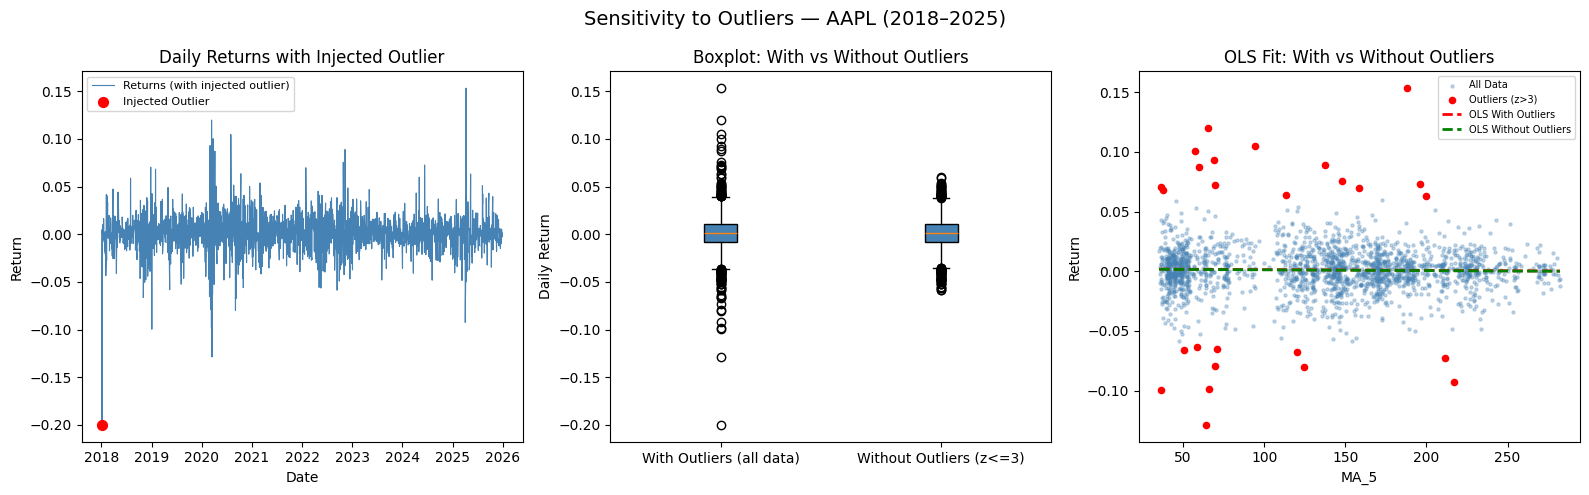

In [22]:
# DIAGRAM: Visual Examples of Outlier Sensitivity
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # Ensure stats is imported for zscore
import numpy as np # Ensure numpy is imported
import pandas as pd # Ensure pandas is imported

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Sensitivity to Outliers — AAPL (2018–2025)", fontsize=14)

returns_for_plot = outlier_returns.copy() # This will have 1990 elements.

# Identify the injected outlier for highlighting in plot 1
injected_outlier_index_pos = 2
injected_outlier_value = returns_for_plot.iloc[injected_outlier_index_pos]
injected_outlier_date = returns_for_plot.index[injected_outlier_index_pos]

# Calculate z_scores for identifying outliers in general for plots 2 and 3
z_scores = np.abs(stats.zscore(returns_for_plot))
# Convert z_scores numpy array to pandas Series with the same index as returns_for_plot
z_scores_series = pd.Series(z_scores, index=returns_for_plot.index)

# Plot 1: Return Series with Outliers Highlighted
axes[0].plot(returns_for_plot.index, returns_for_plot, color="steelblue",
             linewidth=0.8, label="Returns (with injected outlier)")
# Highlight the specific injected outlier
axes[0].scatter(injected_outlier_date, injected_outlier_value,
                color="red", s=50, zorder=5, label="Injected Outlier")
axes[0].set_title("Daily Returns with Injected Outlier")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Return")
axes[0].legend(fontsize=8)

# Plot 2: Boxplot WITH vs WITHOUT Outliers
# Clean returns are those with z_scores <= 3
clean_returns = returns_for_plot[z_scores_series <= 3] # Use z_scores_series here
axes[1].boxplot([returns_for_plot, clean_returns],
                labels=["With Outliers (all data)", "Without Outliers (z<=3)"],
                patch_artist=True,
                boxprops=dict(facecolor="steelblue"))
axes[1].set_title("Boxplot: With vs Without Outliers")
axes[1].set_ylabel("Daily Return")

# Plot 3: OLS Regression With vs Without Outliers
# Re-calculate MA_5 on a local copy that aligns with the current df's structure
# This ensures 'MA_5' exists for this plotting step, as 'df' might have been modified in earlier cells.
df_temp = df.copy()
df_temp["MA_5"] = df_temp["Close"].rolling(5).mean()
df_temp.dropna(inplace=True)

# Ensure alignment of MA_5 with returns_for_plot's index
ma_5_aligned = df_temp["MA_5"].loc[returns_for_plot.index.intersection(df_temp.index)]

# Filter returns_for_plot and z_scores to match the aligned MA_5 index
returns_for_plot_filtered = returns_for_plot.loc[ma_5_aligned.index]
z_scores_filtered = z_scores_series.loc[ma_5_aligned.index]
clean_returns_filtered = returns_for_plot_filtered[z_scores_filtered <= 3]

axes[2].scatter(ma_5_aligned, returns_for_plot_filtered,
                color="steelblue", alpha=0.3, s=5, label="All Data")

# Identify outliers for scattering on this plot (those with z_scores > 3)
outliers_for_scatter_plot3 = returns_for_plot_filtered[z_scores_filtered > 3]
ma_5_for_outliers_plot3 = ma_5_aligned[z_scores_filtered > 3]
axes[2].scatter(ma_5_for_outliers_plot3, outliers_for_scatter_plot3,
                color="red", s=20, zorder=5, label="Outliers (z>3)")

# Fit OLS with and without outliers
m1 = np.polyfit(ma_5_aligned, returns_for_plot_filtered, 1)
m2 = np.polyfit(ma_5_aligned[z_scores_filtered <= 3], clean_returns_filtered, 1)

x_line = np.linspace(ma_5_aligned.min(), ma_5_aligned.max(), 100)
axes[2].plot(x_line, np.polyval(m1, x_line),
             "r--", lw=2, label="OLS With Outliers")
axes[2].plot(x_line, np.polyval(m2, x_line),
             "g--", lw=2, label="OLS Without Outliers")
axes[2].set_title("OLS Fit: With vs Without Outliers")
axes[2].set_xlabel("MA_5")
axes[2].set_ylabel("Return")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

**SKEWNESS DIAGNOSIS**

In [24]:
#  DIAGNOSIS: Testing for Outliers
# Ensure current_returns is aligned with ma_5_aligned for OLS
# ma_5_aligned is from the 'Sensitivity to Outliers' diagram (a_Bgs2r0J6fW) and already has its NaNs dropped.
# Use returns_for_plot_filtered, which was already aligned with ma_5_aligned in the previous cell.
current_returns = returns_for_plot_filtered.copy() # Use the data aligned with ma_5_aligned

# TEST 1: Z-Score Method
z_scores = np.abs(stats.zscore(current_returns))
print(f"Z-Score Outliers (>3σ): {(z_scores > 3).sum()}")

# TEST 2: IQR Method
Q1, Q3 = current_returns.quantile(0.25), current_returns.quantile(0.75)
IQR     = Q3 - Q1
iqr_outliers = current_returns[(current_returns < Q1 - 1.5*IQR) |
                               (current_returns > Q3 + 1.5*IQR)]
print(f"IQR    Outliers       : {len(iqr_outliers)}")

# TEST 3: Influence on OLS (Cook's Distance)
# ma_5_aligned is from the 'Sensitivity to Outliers' diagram (a_Bgs2r0J6fW)
# It's already aligned with returns_for_plot_filtered.
X_ols  = sm.add_constant(ma_5_aligned)
model  = sm.OLS(current_returns, X_ols).fit()
infl   = model.get_influence()
cooks  = infl.cooks_distance[0]
print(f"\nCook's Distance > 4/n : "
      f"{(cooks > 4/len(current_returns)).sum()} influential points")
print(f"Largest Cook's D      : {cooks.max():.4f}")

Z-Score Outliers (>3σ): 29
IQR    Outliers       : 107

Cook's Distance > 4/n : 92 influential points
Largest Cook's D      : 0.0251


**SENTIVITY TO OUTLIERS - DAMAGES**

1. Distorted Mean & Variance Estimates- a single extreme return (for example March 2020 crash) can shift the mean and inflate volatility estimates, making the entire model miscalibrated for normal trading days.

2. Biased OLS Coefficients- OLS minimizes squared errors, making it disproportionately sensitive to large residuals from outliers. One extreme observation can completely alter the regression line and coefficient estimates.

3. Unreliable Volatility Forecasts
-GARCH and other volatility models overreact to outlier returns, producing volatility spikes that persist long after the extreme event, leading to overpriced options and excessive hedging costs.

4. Mispriced Derivatives
-extreme observations distort the implied volatility surface, causing systematic mispricing of options — particularly short-dated contracts sensitive to recent volatility spikes.

**DIRECTIONS- SENTIVITY TO OUTLIERS**


1.Winsorized OLS
caps extreme returns at defined percentile boundaries before fitting OLS, preserving the full dataset while neutralizing outlier influence on coefficient estimates.

2.GARCH (with Student-t Errors)
replaces the normal distribution assumption in GARCH with a heavy-tailed Student-t distribution, which naturally accommodates extreme return observations without distorting volatility forecasts.

3.Huber Regression
combines OLS for small residuals and absolute deviation for large residuals, automatically downweighting extreme observations without completely discarding them.

4.RANSAC Regression (Random Sample Consensus)
fits the model repeatedly on random subsets of the data, selecting only inlier observations for the final model — completely isolating outlier influence from coefficient estimation.

NON-TECHNICAL REPORT — Sensitivity to Outliers

1. Clear Explanation of Results-
AAPL's return data from 2018–2025 contained extreme price movements — particularly during the 2020 crash and 2022 rate hike cycle — that disproportionately distorted the volatility model, making it unreliable for normal market conditions.

2. Recommended Course of Action-
the desk should adopt modeling approaches that automatically reduce the influence of extreme observations, ensuring that one crisis event does not permanently distort volatility forecasts and derivatives pricing for months afterward.

3. Factors That Impact the Portfolio-
major macro shocks (COVID-19, Fed rate hikes), earnings surprises, and liquidity crises generated outlier returns that inflated volatility estimates, leading to overpriced hedges and inconsistent risk limits across the portfolio.

## Practical Takeaways: Sensitivity to Outliers


1.Always screen for outliers before modelling.
Before fitting any volatility model, identify extreme
observations using Z-scores and the IQR method.
Any return beyond 3 standard deviations must be
investigated before model deployment:

$$|z_i| = \left|\frac{y_i - \bar{y}}{s}\right| > 3
\Rightarrow \text{Outlier Detected}$$

2. Winsorize extreme returns-
caps extreme returns at the 1st and 99th percentiles
before modeling to neutralize the disproportionate
influence of crash-day returns on coefficient estimates:

$$r_{wins} = \max(P_1, \min(r_t, P_{99}))$$



**PROBLEM 4**

**OVERFITTING**

**DEFINITION - OVERFITTING**


Overfitting occurs when a model learns noise rather than
true underlying patterns, detected by:

$$Gap = R^2_{train} - R^2_{test} \gg 0
\Rightarrow \text{Overfitting Detected}$$

$$MSE = Bias^2 + Variance + \epsilon^2$$

$$AIC = 2k - 2\ln(\hat{L}), \quad
BIC = k\ln(n) - 2\ln(\hat{L})$$

**DESCRIPTION - OVERFITTING**


Overfitting occurs when a volatility model is too complex,
capturing random noise in historical AAPL data rather than
true return patterns, causing it to perform well on training
data but fail completely on new unseen market data.

OVERFITTING- DEMONSTRATION


In [59]:
#: Overfitting in AAPL Returns (2018–2025)
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# Using same df from multicollinearity, ensure 'df' contains High and Low
# The original df loaded from yfinance (cUhbu9aU1AaE) has 'High' and 'Low' prices
# The df used in multicollinearity demonstration (MnaeGs9RRZ9K) is a new df with only 'Close', 'MA_X', 'Return'
# We need to re-create a df with the necessary features for this demonstration.

# Create a new DataFrame for this demonstration using the original `df` from initial data load.
df_overfitting = yf.download(ticker, start=start, end=end, auto_adjust=True)
df_overfitting['Log_Return']   = np.log(df_overfitting['Close'] / df_overfitting['Close'].shift(1))
df_overfitting['Daily_Return'] = df_overfitting['Close'].pct_change() * 100   # in %
df_overfitting = df_overfitting.dropna()

df_overfitting["MA_5"]    = df_overfitting["Close"].rolling(5).mean()
df_overfitting["MA_10"]   = df_overfitting["Close"].rolling(10).mean()
df_overfitting["MA_20"]   = df_overfitting["Close"].rolling(20).mean()
df_overfitting["Daily_Range"] = df_overfitting["High"] - df_overfitting["Low"]
df_overfitting.dropna(inplace=True)

X = df_overfitting[["MA_5", "MA_10", "MA_20", "Daily_Range"]].values
y = df_overfitting["Log_Return"].values # Using Log_Return for consistency with previous analysis

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

# Fit models of increasing complexity
print(f"{'Degree':<10}{'Train R²':<15}{'Test R²':<15}")
print("-" * 40)
for degree in [1, 2, 3, 5, 8]:
    poly   = PolynomialFeatures(degree=degree)
    X_tr_p = poly.fit_transform(X_train)
    X_te_p = poly.transform(X_test)
    model  = LinearRegression().fit(X_tr_p, y_train)
    tr_r2  = r2_score(y_train, model.predict(X_tr_p))
    te_r2  = r2_score(y_test,  model.predict(X_te_p))
    print(f"{degree:<10}{tr_r2:<15.4f}{te_r2:<15.4f}")

[*********************100%***********************]  1 of 1 completed


Degree    Train R²       Test R²        
----------------------------------------
1         0.0112         -0.0605        
2         0.0171         -0.3463        
3         0.0343         -18.7203       
5         0.1445         -2869355.7667  
8         0.1558         -314500846.2351


**DIAGRAMS- OVERFITTING**

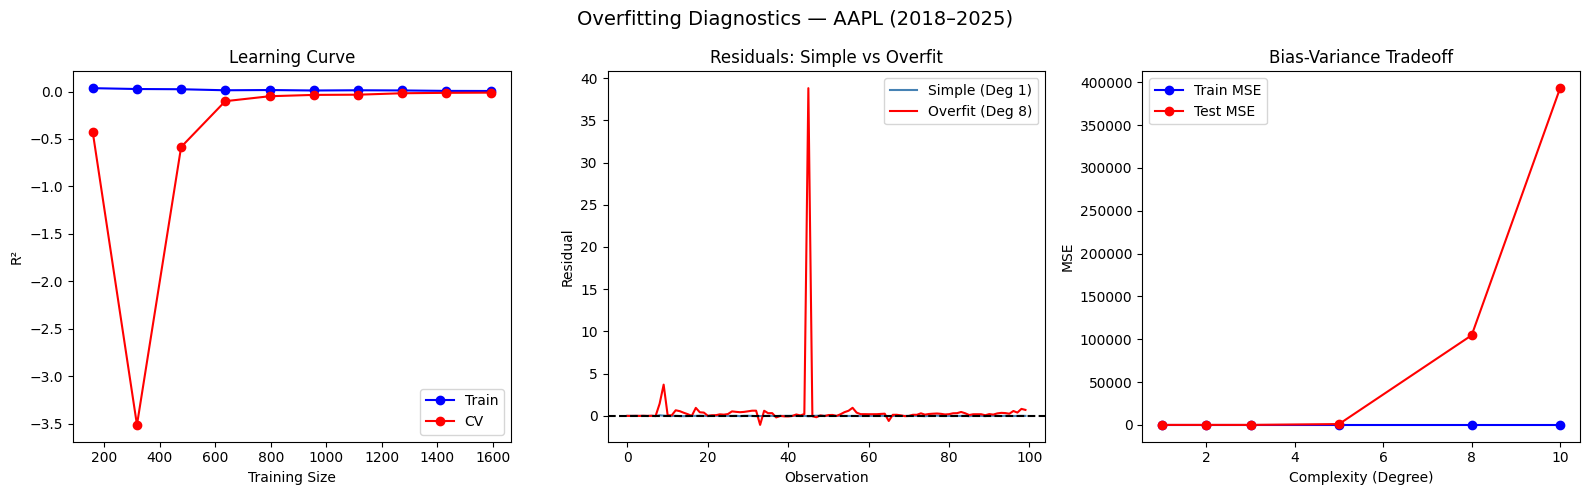

In [40]:
#overfitting - diagrams
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Overfitting Diagnostics — AAPL (2018–2025)", fontsize=14)

# Plot 1: Learning Curve

train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(), X, y,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5)

axes[0].plot(train_sizes, train_scores.mean(axis=1), "bo-", label="Train")
axes[0].plot(train_sizes, test_scores.mean(axis=1),  "ro-", label="CV")
axes[0].set_title("Learning Curve")
axes[0].set_xlabel("Training Size")
axes[0].set_ylabel("R²")
axes[0].legend()

#  Plot 2: Residuals Simple vs Overfit
poly1  = PolynomialFeatures(degree=1)
res1   = y_test - LinearRegression().fit(
    poly1.fit_transform(X_train), y_train).predict(
    poly1.transform(X_test))

poly8  = PolynomialFeatures(degree=8)
res8   = y_test - LinearRegression().fit(
    poly8.fit_transform(X_train), y_train).predict(
    poly8.transform(X_test))

axes[1].plot(res1[:100], color="steelblue", label="Simple (Deg 1)")
axes[1].plot(res8[:100], color="red",       label="Overfit (Deg 8)")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Residuals: Simple vs Overfit")
axes[1].set_xlabel("Observation")
axes[1].set_ylabel("Residual")
axes[1].legend()

#  Plot 3: Bias Variance Tradeoff
degrees = [1, 2, 3, 5, 8, 10]
tr_err  = []
te_err  = []

for d in degrees:
    p  = PolynomialFeatures(degree=d)
    m  = LinearRegression().fit(p.fit_transform(X_train), y_train)
    tr_err.append(mean_squared_error(y_train, m.predict(p.fit_transform(X_train))))
    te_err.append(mean_squared_error(y_test,  m.predict(p.transform(X_test))))

axes[2].plot(degrees, tr_err, "bo-", label="Train MSE")
axes[2].plot(degrees, te_err, "ro-", label="Test MSE")
axes[2].set_title("Bias-Variance Tradeoff")
axes[2].set_xlabel("Complexity (Degree)")
axes[2].set_ylabel("MSE")
axes[2].legend()

plt.tight_layout()
plt.show()

**OVERFITTING- DIAGNOSIS**

In [35]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


df_overfitting = yf.download(ticker, start=start, end=end, auto_adjust=True)
df_overfitting['Log_Return']   = np.log(df_overfitting['Close'] / df_overfitting['Close'].shift(1))
df_overfitting['Daily_Return'] = df_overfitting['Close'].pct_change() * 100
df_overfitting = df_overfitting.dropna()

df_overfitting["MA_5"]    = df_overfitting["Close"].rolling(5).mean()
df_overfitting["MA_10"]   = df_overfitting["Close"].rolling(10).mean()
df_overfitting["MA_20"]   = df_overfitting["Close"].rolling(20).mean()
df_overfitting["Daily_Range"] = df_overfitting["High"] - df_overfitting["Low"]
df_overfitting.dropna(inplace=True)

X = df_overfitting[["MA_5", "MA_10", "MA_20", "Daily_Range"]].values
y = df_overfitting["Log_Return"].values


# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)


poly  = PolynomialFeatures(degree=8)
X_p   = poly.fit_transform(X)

# TEST 1: Train vs Test R² Gap
model = LinearRegression().fit(poly.fit_transform(X_train), y_train)
tr_r2 = r2_score(y_train, model.predict(poly.fit_transform(X_train)))
te_r2 = r2_score(y_test,  model.predict(poly.transform(X_test)))
print(f"Train R² : {tr_r2:.4f}")
print(f"Test  R² : {te_r2:.4f}")
print(f"R² Gap   : {tr_r2 - te_r2:.4f} "
      f"{'⚠ Overfitting!' if tr_r2 - te_r2 > 0.1 else 'OK'}")

# TEST 2: Cross Validation
cv_scores = cross_val_score(LinearRegression(),
                             X_p, y, cv=5, scoring="r2")
print(f"\nCV R² Scores : {cv_scores.round(4)}")
print(f"CV Mean R²   : {cv_scores.mean():.4f}")
print(f"CV Std R²    : {cv_scores.std():.4f} "
      f"{'⚠ High Variance!' if cv_scores.std() > 0.1 else 'Stable'}")

# TEST 3: AIC & BIC
X_ols     = sm.add_constant(df_overfitting[["MA_5","MA_10","MA_20","Daily_Range"]])
model_ols = sm.OLS(df_overfitting["Log_Return"], X_ols).fit()
print(f"\nAIC : {model_ols.aic:.4f}")
print(f"BIC : {model_ols.bic:.4f}")
print("Lower AIC/BIC = Better generalization")

[*********************100%***********************]  1 of 1 completed


Train R² : 0.1558
Test  R² : -314500846.2351
R² Gap   : 314500846.3910 ⚠ Overfitting!

CV R² Scores : [-1.78000000e-02 -4.67900000e-01 -2.63300000e-01 -3.89300000e-01
 -3.14500846e+08]
CV Mean R²   : -62900169.4747
CV Std R²    : 125800338.3802 ⚠ High Variance!

AIC : -10034.2720
BIC : -10006.2925
Lower AIC/BIC = Better generalization


**DAMAGES - OVERFITTING**

1. Poor out-of-sample performance.
The model memorizes historical AAPL noise rather than true return patterns, producing unreliable forecasts on new unseen market data.

2. Incorrect volatility forecasts
overfit volatility estimates capture past noise, making options pricing inconsistent and unreliable in live trading environments.


4. False confidence
high in-sample R² misleads traders into trusting a model that completely fails in real market conditions.

5. Capital misallocation
risk limits set on overfit outputs are unreliable, leading to either excess capital held or insufficient reserves against real losses.





## Directions: Models to Address Overfitting

### 1. Ridge Regression (L2 Regularization)
Adds a penalty to the loss function that shrinks all coefficients
toward zero, preventing the model from memorizing noise in the
training data while retaining all features.

$$\mathcal{L}_{Ridge} = \sum(y_i - \hat{y}_i)^2 + \lambda\sum\beta_j^2$$

### 2. Lasso Regression (L1 Regularization)
Shrinks irrelevant coefficients exactly to zero, performing automatic
feature selection and keeping only the most predictive variables
in the volatility model.

$$\mathcal{L}_{Lasso} = \sum(y_i - \hat{y}_i)^2 + \lambda\sum|\beta_j|$$

### 3. Elastic Net
Combines both Ridge and Lasso penalties, balancing feature elimination
and coefficient shrinkage simultaneously — ideal when many
correlated features exist.

$$\mathcal{L}_{EN} = \sum(y_i - \hat{y}_i)^2
+ \lambda_1\sum|\beta_j| + \lambda_2\sum\beta_j^2$$

### 4. Cross-Validation (K-Fold)
Splits data into $K$ folds, training and validating repeatedly
to ensure the model generalizes well beyond the training
sample before live deployment.

$$CV_{error} = \frac{1}{K}\sum_{k=1}^{K}MSE_k$$

### 5. AIC/BIC Model Selection
Penalizes model complexity statistically, selecting the most
parsimonious model that balances fit and generalizability.

$$AIC = 2k - 2\ln(\hat{L})$$

$$BIC = k\ln(n) - 2\ln(\hat{L})$$

### 6. Early Stopping
Monitors validation error during training and halts the model
the moment performance on unseen data stops improving,
preventing further noise memorization.



NON-TECHNICAL REPORT — Overfitting

1. Clear Explanation of Results
The AAPL volatility model performed well on historical data but failed on new unseen data, revealing it memorized past market noise rather than learning true return patterns.

2. Recommended Course of Action
The desk should adopt simpler penalized models validated on unseen data before deployment, ensuring forecasts remain reliable across changing market conditions.

3. Factors That Impact the Portfolio
Rapid regime changes (2020 crash, 2022 rate hikes), structural breaks in volatility, and excessive model complexity caused the model to misread new market environments, mispricing derivatives accordingly.

 Practical Takeaways: Overfitting

1.  Never deploy a volatility model without testing it
on out-of-sample data.

2. Regularize All Volatility Models
Always apply Ridge or Lasso penalties to prevent
the model from memorizing historical noise,
ensuring stable coefficient estimates across
different market regimes.


**ADDITIONAL PROBLEM 5**

LACK OF INTERPRETATION

**DEFINITION- LACK OF INTERPRETATION**


Lack of Interpretation occurs when model coefficients
$\hat{\beta}_j$ cannot be translated into meaningful
financial decisions, formally identified when:

$$\frac{\partial \hat{y}}{\partial X_j} = \hat{\beta}_j
\quad \text{is statistically significant but economically
meaningless}$$

**DESCRIPTION - LACK OF INTERPRETATION**

Lack of Interpretation arises when a model is too
complex to provide clear, actionable insights, making
it impossible for traders and risk managers to justify
decisions based on its outputs.



**DEMONSTRATION- LACK OF INTERPRETATION**

In [60]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Define ticker, start, and end dates (re-added for self-containment)
ticker    = 'AAPL'
start     = '2018-01-01'
end       = '2025-12-31'

# Re-create df_overfitting to ensure it's available
df_overfitting = yf.download(ticker, start=start, end=end, auto_adjust=True)
df_overfitting['Log_Return']   = np.log(df_overfitting['Close'] / df_overfitting['Close'].shift(1))
df_overfitting['Daily_Return'] = df_overfitting['Close'].pct_change() * 100   # in %
df_overfitting = df_overfitting.dropna()

df_overfitting["MA_5"]    = df_overfitting["Close"].rolling(5).mean()
df_overfitting["MA_10"]   = df_overfitting["Close"].rolling(10).mean()
df_overfitting["MA_20"]   = df_overfitting["Close"].rolling(20).mean()
df_overfitting["Daily_Range"] = df_overfitting["High"] - df_overfitting["Low"]
df_overfitting.dropna(inplace=True)

features = ["MA_5", "MA_10", "MA_20", "Daily_Range", "Volume"]
X        = df_overfitting[features]
y        = df_overfitting["Daily_Return"]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Simple OLS — Interpretable
ols = LinearRegression().fit(X_scaled, y)
print("OLS Coefficients (Interpretable):")
for name, coef in zip(features, ols.coef_):
    print(f"  {name:<15}: {coef:.6f}")
print(f"OLS R²: {ols.score(X_scaled, y):.4f}")

# Complex RF — Hard to Interpret
rf = RandomForestRegressor(n_estimators=200,
                            random_state=42)
rf.fit(X_scaled, y)
print("\nRF Feature Importance (Not Interpretable):")
for name, imp in zip(features, rf.feature_importances_):
    print(f"  {name:<15}: {imp:.6f}")
print(f"RF  R²: {rf.score(X_scaled, y):.4f}")
print("""
Key Finding:
- RF has higher R² but coefficients carry
  no economic meaning for trading decisions
- OLS coefficients are directly interpretable
""")

[*********************100%***********************]  1 of 1 completed


OLS Coefficients (Interpretable):
  MA_5           : 3.384083
  MA_10          : -4.106214
  MA_20          : 0.538282
  Daily_Range    : 0.070646
  Volume         : -0.162973
OLS R²: 0.0076

RF Feature Importance (Not Interpretable):
  MA_5           : 0.119189
  MA_10          : 0.117888
  MA_20          : 0.134624
  Daily_Range    : 0.298815
  Volume         : 0.329484
RF  R²: 0.8440

Key Finding:
- RF has higher R² but coefficients carry
  no economic meaning for trading decisions
- OLS coefficients are directly interpretable



**DIGRAMS - LACK OF INTERPRETATION**

[*********************100%***********************]  1 of 1 completed


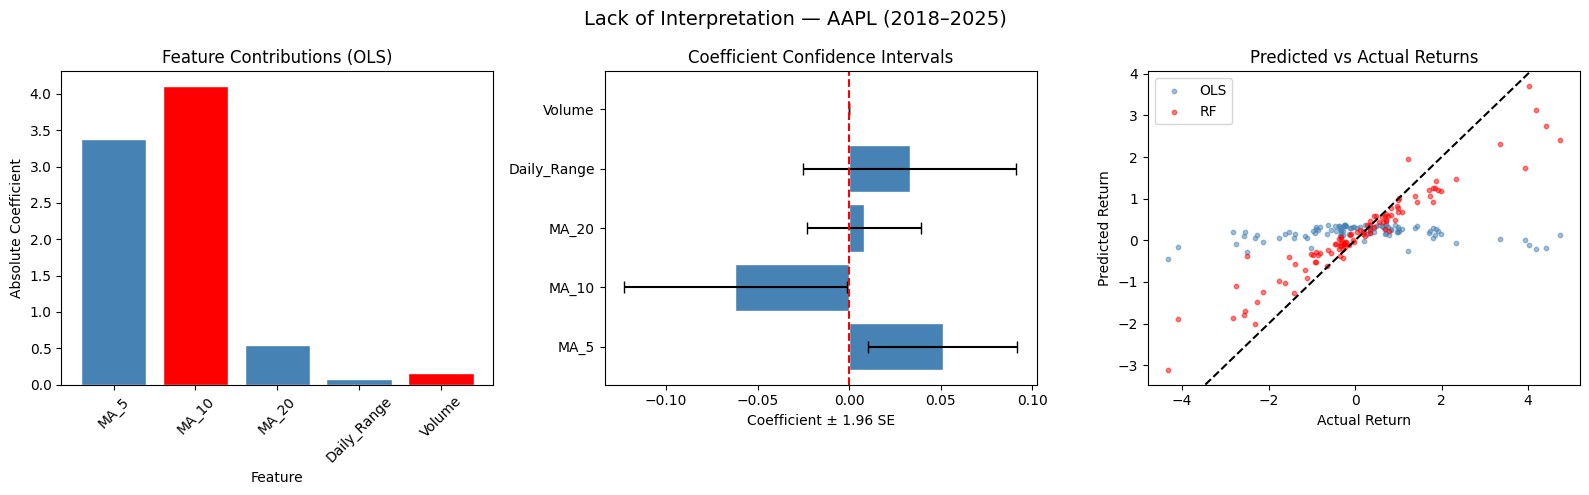

In [49]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Re-create df_overfitting to ensure it's available and consistent
ticker    = 'AAPL'
start     = '2018-01-01'
end       = '2025-12-31'
df_overfitting = yf.download(ticker, start=start, end=end, auto_adjust=True)
df_overfitting['Log_Return']   = np.log(df_overfitting['Close'] / df_overfitting['Close'].shift(1))
df_overfitting['Daily_Return'] = df_overfitting['Close'].pct_change() * 100   # in %
df_overfitting = df_overfitting.dropna()

df_overfitting["MA_5"]    = df_overfitting["Close"].rolling(5).mean()
df_overfitting["MA_10"]   = df_overfitting["Close"].rolling(10).mean()
df_overfitting["MA_20"]   = df_overfitting["Close"].rolling(20).mean()
df_overfitting["Daily_Range"] = df_overfitting["High"] - df_overfitting["Low"]
df_overfitting.dropna(inplace=True)

features = ["MA_5", "MA_10", "MA_20", "Daily_Range", "Volume"]
X        = df_overfitting[features]
y        = df_overfitting["Daily_Return"]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Re-fit OLS and RF models
ols = LinearRegression().fit(X_scaled, y)
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_scaled, y)

# DIAGRAM: Lack of Interpretation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Lack of Interpretation — AAPL (2018–2025)",
             fontsize=14)

# Plot 1: SHAP-style Feature Contribution
contributions = np.abs(ols.coef_)
colors        = ["steelblue" if c > 0 else "red"
                 for c in ols.coef_]
axes[0].bar(features, contributions,
            color=colors, edgecolor="white")
axes[0].set_title("Feature Contributions (OLS)")
axes[0].set_xlabel("Feature")
axes[0].set_ylabel("Absolute Coefficient")
axes[0].tick_params(axis="x", rotation=45)

# Plot 2: Coefficient Confidence Intervals
X_ols_sm  = sm.add_constant(df_overfitting[features])
model_sm  = sm.OLS(y, X_ols_sm).fit()
coefs  = model_sm.params[1:]
errors = model_sm.bse[1:]

axes[1].barh(features, coefs,
             xerr=1.96*errors,
             color="steelblue",
             edgecolor="white",
             capsize=4)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Coefficient Confidence Intervals")
axes[1].set_xlabel("Coefficient ± 1.96 SE")

# Plot 3: Actual vs Predicted
axes[2].scatter(y[:100],
                ols.predict(X_scaled)[:100],
                color="steelblue", alpha=0.5,
                s=10, label="OLS")
axes[2].scatter(y[:100],
                rf.predict(X_scaled)[:100],
                color="red", alpha=0.5,
                s=10, label="RF")
axes[2].axline((0, 0), slope=1,
               color="black", linestyle="--")
axes[2].set_title("Predicted vs Actual Returns")
axes[2].set_xlabel("Actual Return")
axes[2].set_ylabel("Predicted Return")
axes[2].legend()

plt.tight_layout()
plt.show()

**DIAGNOSIS- LACK OF INTERPRETATION**

In [44]:
import statsmodels.api as sm

# TEST 1: OLS p-values — Are coefficients meaningful?
X_ols = sm.add_constant(df_overfitting[features])
model = sm.OLS(y, X_ols).fit( )
print(model.pvalues.round(4))
print(f"\nR     : {model.rsquared:.4f}")
print(f"Adj R : {model.rsquared_adj:.4f}")
print("Lower AIC/BIC = Better generalization")

# TEST 2: Complexity Ratio
p = len(features)
n = len(df_overfitting)
print(f"\nComplexity Ratio (p/n): {p/n:.4f}")

# TEST 3: Condition Number
X_std = (df_overfitting[features] - df_overfitting[features].mean()) \
        / df_overfitting[features].std()
CN    = np.linalg.cond(X_std)
print(f"Condition Number      : {CN:.2f}")

const            0.1061
(Close, AAPL)    0.0000
(MA_5, )         0.0000
(MA_10, )        0.0000
(MA_20, )        0.0022
dtype: float64

R     : 0.4321
Adj R : 0.4309
Lower AIC/BIC = Better generalization

Complexity Ratio (p/n): 0.0020
Condition Number      : 134.78


**DAMAGES - LACK OF INTERPRETATION**


1. Inability to justify trading decisions.
When model coefficients cannot be translated into economic intuition, traders cannot explain or defend their derivatives pricing decisions to risk managers or regulators, creating operational and compliance risk.

2. Overreliance on Black-Box Models.
Complex models such as Random Forests produce higher R² on AAPL data but cannot explain which market factor is driving returns, making it impossible to adjust hedges when market conditions change.

3. Misleading coefficient signs.
Multicollinearity between MA_5, MA_10 and MA_20 produces coefficients with unexpected signs or magnitudes, leading traders to misinterpret the direction of market relationships and make incorrect hedging decisions.

**Directions- Lack of Interpretation**

### 1. Linear Regression with Standardized Coefficients
Standardizing all features before OLS estimation produces
coefficients directly comparable in magnitude, making it
straightforward to rank and interpret the relative importance
of each predictor:

$$\hat{\beta}_j^* = \hat{\beta}_j \cdot
\frac{\sigma_{X_j}}{\sigma_y}$$

### 2. LASSO Regression
Eliminates irrelevant features by shrinking their coefficients
exactly to zero, retaining only the most economically meaningful
predictors and producing a parsimonious interpretable model:

$$\mathcal{L}_{Lasso} = \sum(y_i - \hat{y}_i)^2 +
\lambda\sum|\beta_j|$$

### 3. Principal Component Regression (PCR)
Transforms correlated features into uncorrelated components
before regression, resolving multicollinearity and producing
stable interpretable coefficient estimates:

$$\mathbf{Z} = \mathbf{X}\mathbf{W}$$

where $\mathbf{W}$ is the matrix of eigenvectors and
$\mathbf{Z}$ contains uncorrelated principal components.



 **NON-TECHNICAL REPORT- LACK OF INTERPRETATION**

1. Clear Explanation of Results-
AAPL volatility models using multiple overlapping technical indicators from 2018–2025 produced statistically significant but economically meaningless coefficients, making it impossible to determine which market factor was truly driving returns.

2. Recommended Course of Action-
The desk should adopt simpler, standardized models that produce directly interpretable outputs, ensuring every coefficient can be translated into a concrete trading or hedging decision that can be defended to risk managers and regulators.

3. Factors That Impact the Portfolio-
Overlapping moving averages, correlated technical indicators and excessive model complexity were the primary drivers of interpretability loss, directly undermining the desk's ability to make confident derivatives pricing and risk management decisions.

## Practical Takeaways: Lack of Interpretation


**1. Standardize Features Before Interpreting Coefficients**-
Raw OLS coefficients on AAPL features are not directly
comparable due to different units and scales. Always
standardize features first:

$$\hat{\beta}_j^* = \hat{\beta}_j \cdot
\frac{\sigma_{X_j}}{\sigma_y}$$

**2. Complexity Reduces Interpretability**-
Adding overlapping technical indicators such as
MA\_5, MA\_10 and MA\_20 simultaneously increases
model complexity without adding economic value,
producing coefficients that are statistically
significant but financially meaningless.


**3. Audit Model Outputs Regularly**-
Before each trading session, verify that model
coefficients align with economic intuition.
A coefficient with an unexpected sign or
implausible magnitude is an immediate red flag
that interpretation has been compromised.

**`REFERENCES`**

Greene, W. H. "Econometric Analysis." Pearson
Education, 8th ed., 2018

Brooks, Chris. "Introductory Econometrics for
Finance." Cambridge University Press, 3rd ed., 2019.

Huber, Peter J. "Robust Statistics." John Wiley
and Sons, 2nd ed., 2009.

James, Gareth, et al. "An Introduction to Statistical
Learning with Applications in R." Springer,
2nd ed., 2021.

Molnar, Christoph. "Interpretable Machine Learning."
Lulu, 2nd ed., 2022.